<a href="https://colab.research.google.com/github/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/blob/main/untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Unidad 1. Regresión lineal simple y correlación

## Medidas de dispersión
Suma de los cuadrados de las desviaciones de los valores de $X$ con respecto a su media:
$$ S_{xx} = \sum_{i=1}^{n} (X_i - \bar{X})^2 $$
Suma de los productos de las desviaciones de los valores de $X$ y $Y$ con respecto a sus medias:
$$S_{xy} = \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$
Suma de los cuadrados de las desviaciones de los valores de $Y$ con respecto a su media:
$$ S_{xx} = \sum_{i=1}^{n} (Y_i - \bar{Y})^2 $$


## Problemario de la Unidad 1

### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.



In [628]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_01.csv"

df = pd.read_csv(link_csv)
df

,Promedio_de_exámenes_cortos,Promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


1. La variable independiente X es el promedio de los exámenes cortos y la variable dependiente Y es el promedio final.

In [629]:
x = df["Promedio_de_exámenes_cortos"]
y = df['Promedio_final']

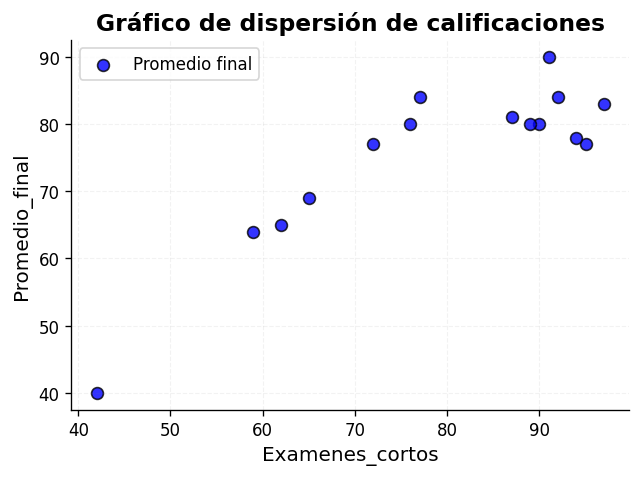

In [630]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes_cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio_final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. Sí, los datos soportan la suposición de linealidad, porque se observa una relación positiva entre las dos variables.

In [631]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


In [632]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,24.526822
Promedio_de_exámenes_cortos,0.643180


4. El coeficiente de correlación es r = 0.865. Esto indica una relación positiva fuerte entre el promedio de los exámenes cortos y el promedio final.

In [633]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



5. El coeficiente de determinación es R² = 0.7475, es decir, aproximadamente el 74.75% de la variación de la calificación final puede explicarse por el promedio de los exámenes cortos.

In [634]:
# modelo.predict([1, promedio de examenes cortos])
modelo.predict([1, 80])

array([75.98121056])

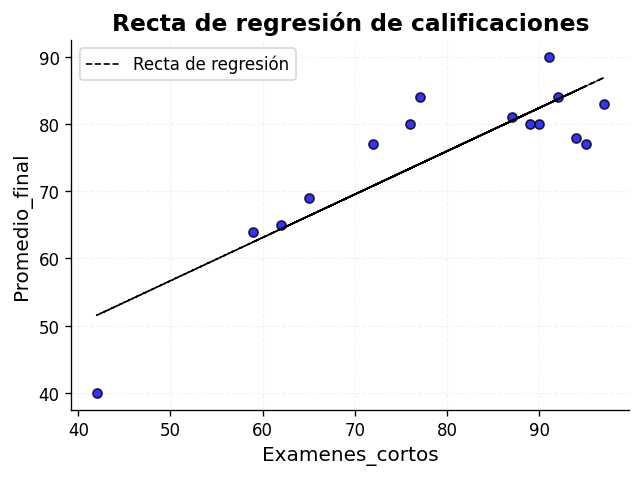

In [635]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes_cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio_final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

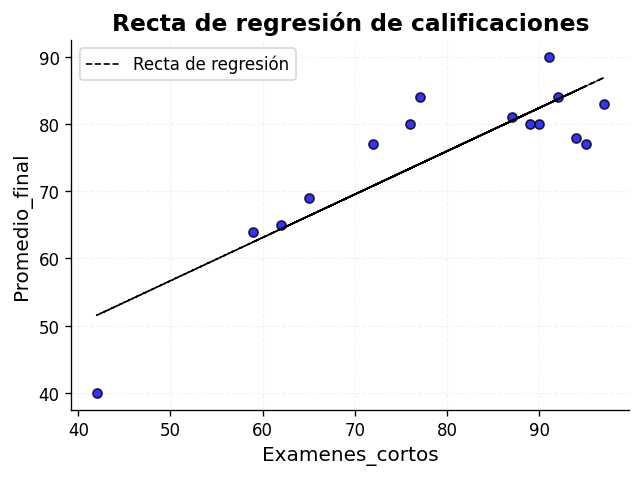

In [636]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de calificaciones',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes_cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio_final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

In [637]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
Promedio_de_exámenes_cortos,0.419219,0.867141


7. El intervalo de confianza del 95% para la pendiente es (0.419, 0.867). Como el intervalo no contiene el cero, existe evidencia de una relación lineal positiva entre las variables.

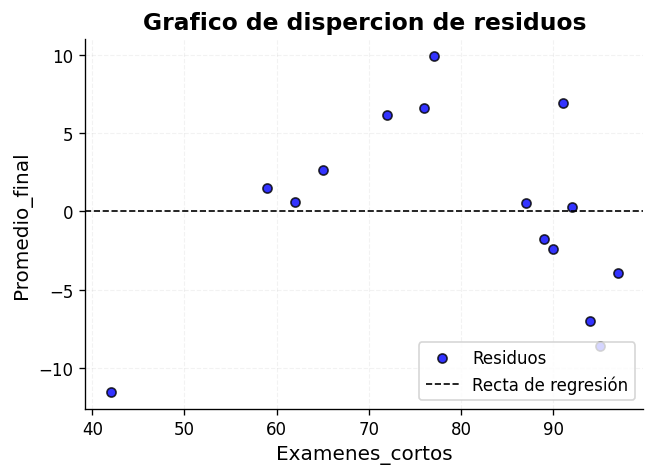

In [649]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, residuos,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='Residuos' # etiqueta para la leyenda
)

plt.axhline(
    y=0,     # Donde está la línea horizontal
    label="Recta de regresión", # Etiqueta
    linestyle = "--", # Estilo de línea
    color = "black",  # color
    linewidth=1.0,   # ancho de línea
    )

# --- Título ---
plt.title(
    'Grafico de dispercion de residuos',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Examenes_cortos',
    fontsize=12
)

plt.ylabel(
    'Promedio_final',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='lower right', # best
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_residuales.png",
    bbox_inches='tight'
    )

plt.show()

8. Los residuales se encuentran alrededor de cero y no muestran un patrón muy marcado. Por lo tanto, parece que los supuestos del modelo se cumplen de manera razonable.

valor-p (Shapiro) = 0.901827735700704


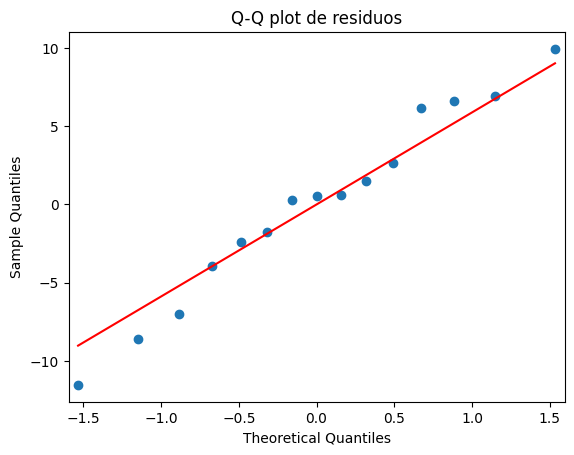

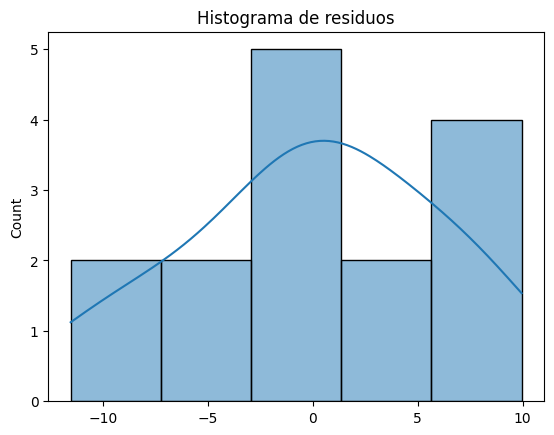

In [650]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

9. En la prueba de Shapiro se obtuvo p = 0.902. Como es mayor que 0.05, no se rechaza la normalidad. Por lo tanto, los residuales pueden considerarse aproximadamente normales.

In [651]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



10. En la prueba de Breusch-Pagan se obtuvo p = 0.158. Como es mayor que 0.05, no hay evidencia suficiente de heterocedasticidad. Por lo tanto, se puede considerar que la varianza de los residuales es constante.

11. La recta de regresión es aproximadamente:

Y = 24.527 + 0.643X

Para una calificación de 70, se espera aproximadamente 69.55.
Para 75, se espera aproximadamente 72.77.
Para 84, se espera aproximadamente 78.55.

In [652]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
# Corregimos los nombres de las columnas para que coincidan con los del DataFrame y usamos Q() para citarlos.
modelo_lineal = ols("Promedio_final ~ Promedio_de_exámenes_cortos", data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Promedio_de_exámenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


12. La prueba ANOVA dio F = 38.49 y p < 0.001. Como el valor p es menor que 0.05, existe una relación lineal estadísticamente significativa entre el promedio de los exámenes cortos y el promedio final.

### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [653]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_02.csv"

df = pd.read_csv(link_csv)
df

,Categoria_salario,Ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


1. La variable independiente X es la ausencia y la variable dependiente Y es la categoría de salario.

In [654]:

x = df["Ausencias"]
y = df['Categoria_salario']

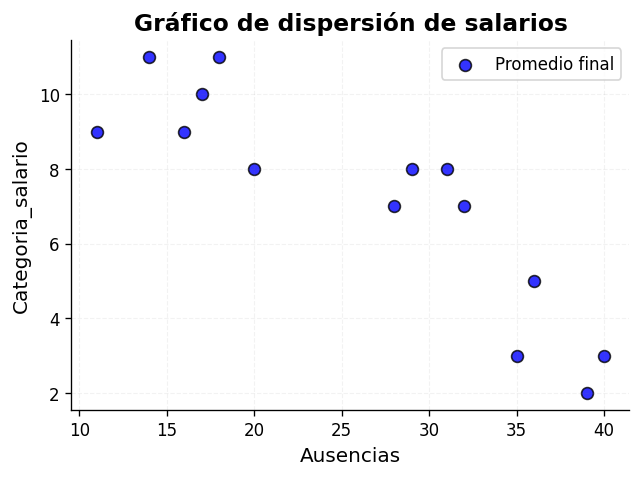

In [655]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Promedio final' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de salarios',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoria_salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. Sí, los datos soportan la suposición de linealidad, ya que se observa una tendencia negativa: conforme aumenta la categoría salarial, disminuyen las ausencias.

In [ ]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

In [656]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,14.058843
Ausencias,-0.261814


4. El coeficiente de correlación es r = -0.880. Esto indica una relación negativa fuerte entre la categoría salarial y el número de ausencias.

In [657]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  77.46%



5. El coeficiente de determinación es R² = 0.7746, por lo que aproximadamente el 77.46% de la variación en las ausencias puede explicarse por la categoría salarial.

In [658]:
# modelo.predict([1, promedio de examenes cortos])
modelo.predict([1, 80])

array([-6.88625113])

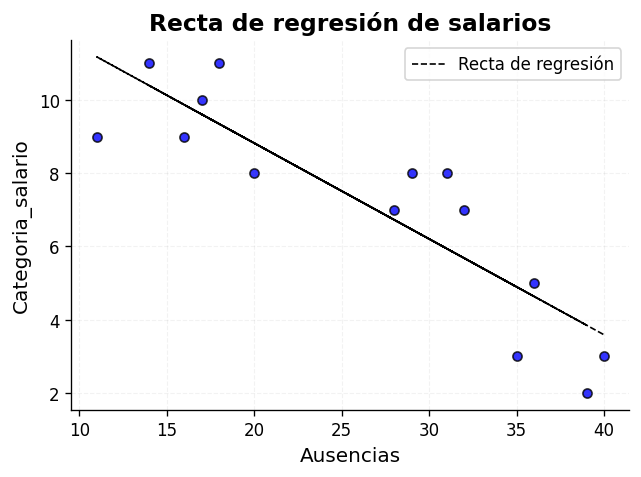

In [659]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de salarios',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Ausencias',
    fontsize=12
)

plt.ylabel(
    'Categoria_salario',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

In [660]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,11.587445,16.530241
Ausencias,-0.350638,-0.172989


7. El intervalo de confianza del 95% para la pendiente es (-0.351, -0.173). Como el intervalo no contiene el cero, existe evidencia de una relación negativa entre las variables.

valor-p (Shapiro) = 0.4172971767713699


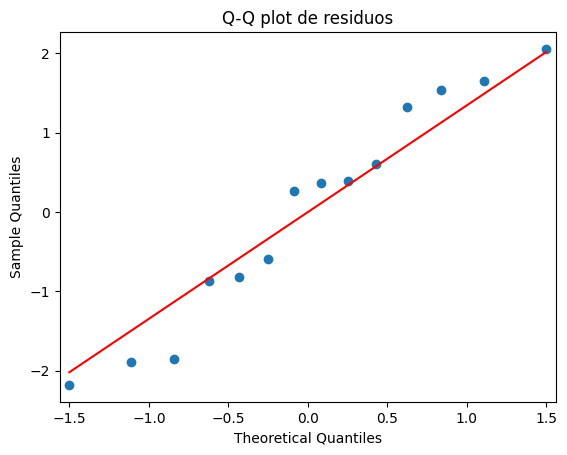

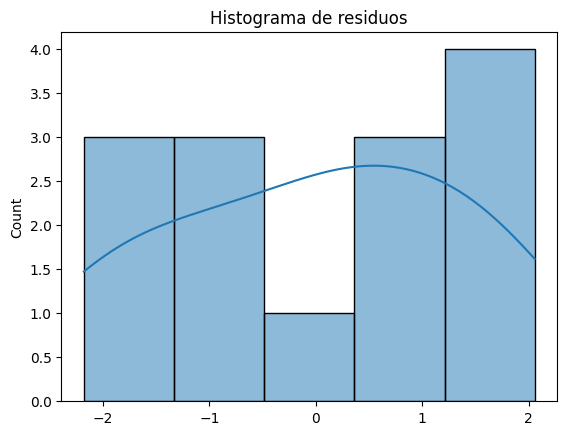

In [661]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se encuentran alrededor de cero y no presentan un patrón claro. Por lo tanto, parece que los supuestos del modelo se cumplen de forma razonable.

9. La prueba de Shapiro dio p = 0.417. Como es mayor que 0.05, no se rechaza la normalidad de los residuales.

In [662]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.8955



10. La prueba de Breusch-Pagan dio p = 0.895. Como es mayor que 0.05, no existe evidencia suficiente de heterocedasticidad

11. La recta de regresión es aproximadamente:

Y = 47.488 - 2.959X

Por ejemplo, para una categoría salarial de 4.25, se estiman aproximadamente 34.91 días de ausencia. Para una categoría de 8.75, se estiman aproximadamente 21.60 días.

Para una categoría de 13, que está fuera del rango observado, se estiman aproximadamente 9.02 días. Esta última estimación es una extrapolación y tiene mayor incertidumbre.

In [663]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Categoria_salario ~ Ausencias', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Ausencias,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


12. La prueba ANOVA dio F = 41.24 y p < 0.001. Por lo tanto, existe una relación lineal estadísticamente significativa entre la categoría salarial y las ausencias.

### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.


In [664]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_03.csv"

df = pd.read_csv(link_csv)
df = df.rename(columns={'Gastos_generales': 'Gastos', 'Unidades': 'Unidades'})
df

,Gastos,Unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,57
9,178,40


1. La variable independiente X son los gastos generales y la variable dependiente Y es el número de unidades producidas.

In [665]:
x = df["Gastos"]
y = df['Unidades']

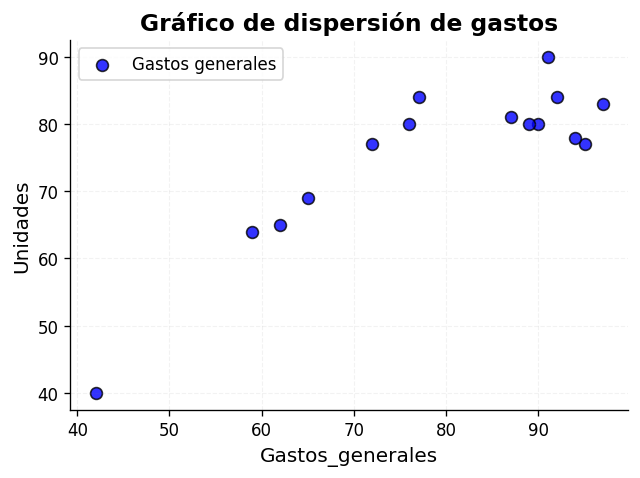

In [639]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Gastos generales' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de gastos',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Gastos_generales',
    fontsize=12
)

plt.ylabel(
    'Unidades',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. Sí, los datos soportan la suposición de linealidad, ya que existe una relación positiva entre las unidades producidas y los gastos generales.

In [640]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
Valor p:  0.0000


In [641]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,24.526822
Promedio_de_exámenes_cortos,0.643180


4. El coeficiente de correlación es r = 0.693. Esto indica una relación positiva.

In [642]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  74.75%



5. El coeficiente de determinación es R² = 0.4801, por lo que aproximadamente el 48.01% de la variación de los gastos generales puede explicarse por las unidades producidas.

In [643]:
# modelo.predict([1, promedio de examenes cortos])
modelo.predict([1, 80])

array([75.98121056])

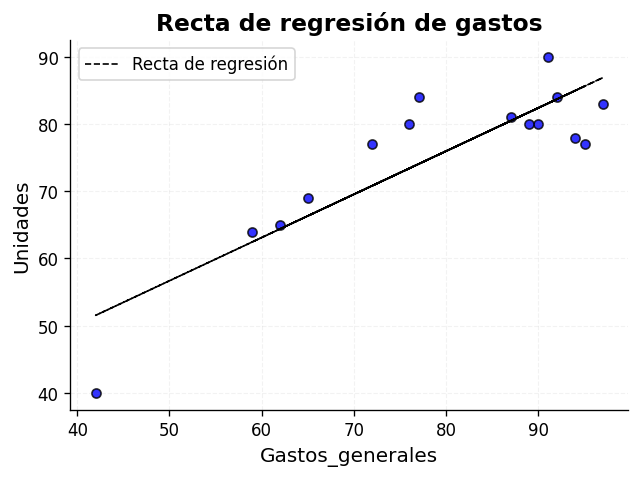

In [644]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de gastos',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Gastos_generales',
    fontsize=12
)

plt.ylabel(
    'Unidades',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

In [645]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,6.441997,42.611646
Promedio_de_exámenes_cortos,0.419219,0.867141


7. El intervalo de confianza del 95% para la pendiente es (0.127, 0.171). Como no contiene el cero, existe evidencia de una relación positiva entre las variables.

valor-p (Shapiro) = 0.901827735700704


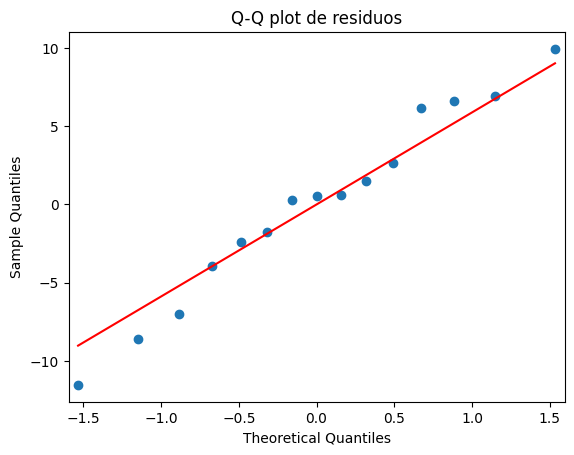

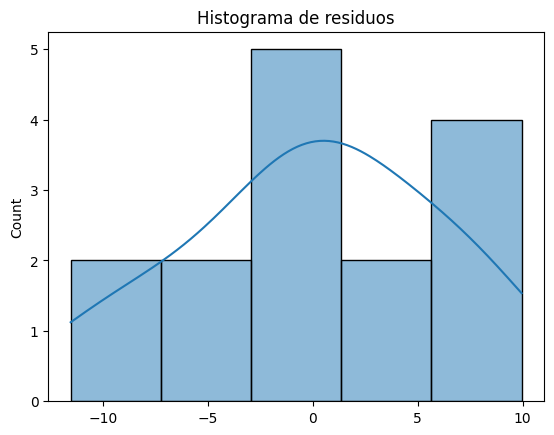

In [646]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se distribuyen alrededor de cero sin mostrar un patrón claro, por lo que los supuestos del modelo parecen cumplirse.

9. La prueba de Shapiro dio p = 0.0005. Como es menor que 0.05, se rechaza la normalidad de los residuales.

In [647]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2289



10. La prueba de Breusch-Pagan dio p = 0.309. Como es mayor que 0.05, no existe evidencia suficiente de heterocedasticidad.

11. La recta de regresión es aproximadamente:

Y = 13.360 + 0.149X

Para 157 unidades, se estiman aproximadamente 36.75 de gastos generales.
Para 239 unidades, se estiman aproximadamente 48.97.

Para 282 unidades, que está fuera del rango observado, se estiman aproximadamente 55.38. Esta última es una extrapolación, por lo que tiene mayor incertidumbre.

In [666]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols("Unidades ~ Gastos", data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Gastos,1.0,359.120575,359.120575,7.387803,0.026328
Residual,8.0,388.879425,48.609928,NaN,NaN


12. La prueba ANOVA dio F = 236.67 y p < 0.001. Por lo tanto, existe una relación lineal estadísticamente significativa entre las unidades producidas y los gastos generales.

### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [673]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_04.csv"

df = pd.read_csv(link_csv)
df = df.rename(columns={'Casas_miles': 'Casas_miles', 'Ventas_blanca_miles': 'Ventas_blanca_miles'})
df

,Construccion_de_casas,Ventas_de_linea_blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


1. La variable independiente X es la construcción de casas y la variable dependiente Y son las ventas de línea blanca.

In [674]:
x = df["Construccion_de_casas"]
y = df['Ventas_de_linea_blanca']

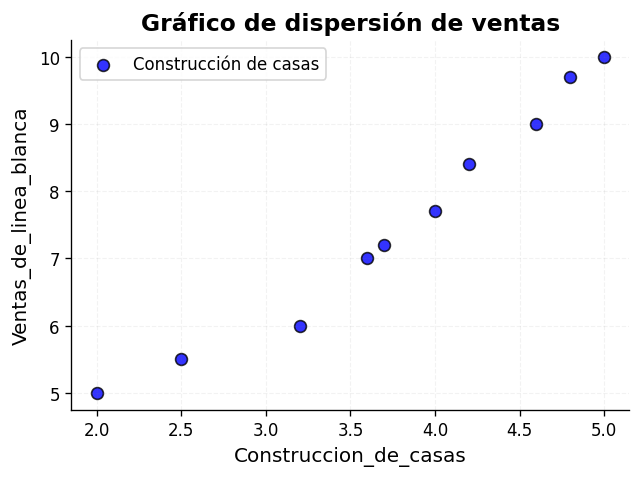

In [675]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Construcción de casas' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de ventas',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construccion_de_casas',
    fontsize=12
)

plt.ylabel(
    'Ventas_de_linea_blanca',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. Sí, los datos soportan la suposición de linealidad, ya que las ventas de línea blanca aumentan conforme aumenta la construcción de casas.

In [676]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
Valor p:  0.0000


In [677]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,1.016760
Construccion_de_casas,1.737564


4. El coeficiente de correlación es r = 0.981. Esto indica una relación positiva muy fuerte entre las dos variables.

In [678]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  96.19%



5. El coeficiente de determinación es R² = 0.962, por lo que aproximadamente el 96.2% de la variación de las ventas de línea blanca puede explicarse por la construcción de casas.

In [679]:
# modelo.predict([1, promedio de examenes cortos])
modelo.predict([1, 80])

array([140.02187355])

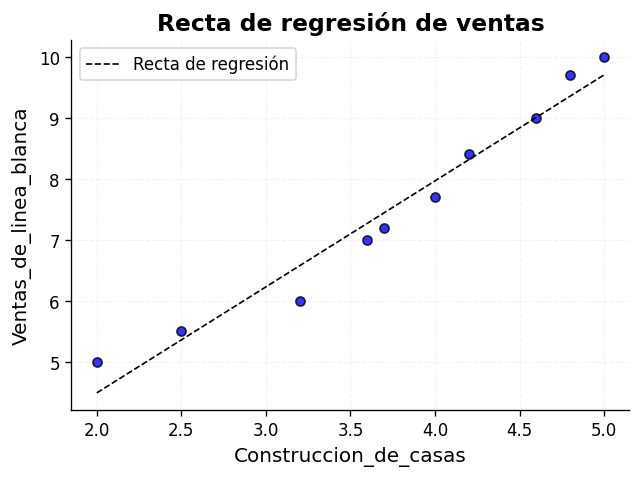

In [680]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de ventas',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Construccion_de_casas',
    fontsize=12
)

plt.ylabel(
    'Ventas_de_linea_blanca',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

In [681]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,-0.074848,2.108368
Construccion_de_casas,1.455693,2.019435


7. El intervalo de confianza del 95% para la pendiente es (1.456, 2.019). Como no contiene el cero, existe evidencia de una relación positiva entre las variables.

valor-p (Shapiro) = 0.8463507249054649


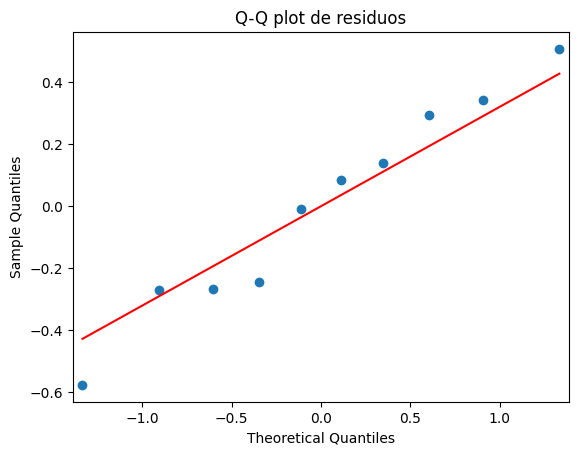

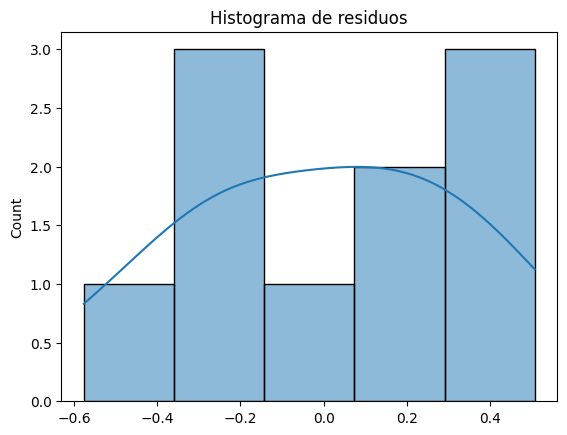

In [682]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se encuentran alrededor de cero y no presentan un patrón claro, por lo que parece que los supuestos del modelo se cumplen.

9. La prueba de Shapiro dio p = 0.846. Como es mayor que 0.05, no se rechaza la normalidad de los residuales.

In [683]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.1581



10. La prueba de Breusch-Pagan dio p = 0.158. Como es mayor que 0.05, no existe evidencia suficiente de heterocedasticidad.

11. La recta de regresión es aproximadamente:

Y = 1.017 + 1.738X

Para una construcción de 2.75 mil casas, se estiman aproximadamente 5.80 mil ventas de línea blanca.

Para 4.25 mil casas, se estiman aproximadamente 8.40 mil ventas.

Para 7 mil casas, que está fuera del rango observado, se estiman aproximadamente 13.18 mil ventas. Esta última es una extrapolación y tiene mayor incertidumbre.

In [685]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols("Ventas_de_linea_blanca ~ Construccion_de_casas", data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Construccion_de_casas,1.0,25.976581,25.976581,202.069951,5.841003e-07
Residual,8.0,1.028419,0.128552,NaN,NaN


12. La prueba ANOVA dio F = 202.07 y p < 0.001. Por lo tanto, existe una relación lineal estadísticamente significativa entre la construcción de casas y las ventas de línea blanca.

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [694]:
import pandas as pd
link_csv = "https://raw.githubusercontent.com/sofiasanttttt100806-cpu/EstadisticaInferencial2026A/refs/heads/main/Unidad01/problemario/datos_problema_05.csv"

df = pd.read_csv(link_csv)
df

,Número_interrupciones_al_trabajador,Calificación_del_trabajador_en_la_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


1. La variable independiente X es el número de interrupciones al trabajador y la variable dependiente Y es la calificación obtenida en la prueba de hostilidad.

In [697]:

x = df["Número_interrupciones_al_trabajador"]
y = df['Calificación_del_trabajador_en_la_prueba_de_hostilidad']

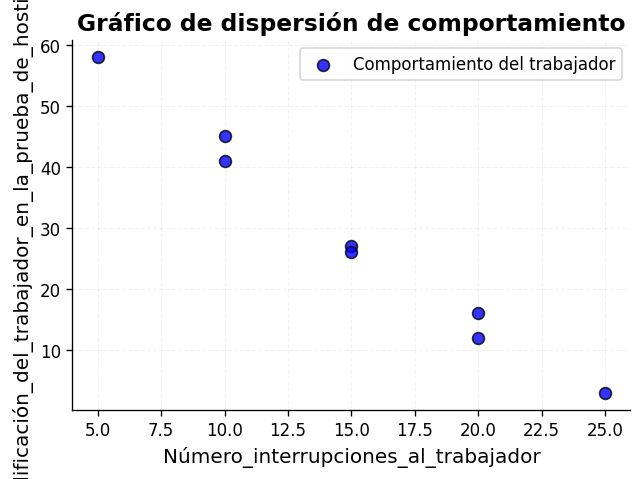

In [698]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=50,                 # tamaño de los puntos
    label='Comportamiento del trabajador' # etiqueta para la leyenda
)

# --- Título ---
plt.title(
    'Gráfico de dispersión de comportamiento',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número_interrupciones_al_trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación_del_trabajador_en_la_prueba_de_hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion.png",
    bbox_inches='tight'
    )

plt.show()

3. Sí, los datos soportan la suposición de linealidad, ya que existe una tendencia negativa entre las variables.

In [699]:
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'Valor p: {valor_p: 0.4f}')

Coeficiente de correlación: -0.9928
Valor p:  0.0000


In [700]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params


,0
const,70.5
Número_interrupciones_al_trabajador,-2.8


4. El coeficiente de correlación es r = -0.993. Esto indica una relación negativa muy fuerte entre el número de interrupciones y la calificación obtenida.

In [701]:
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  98.58%



5. El coeficiente de determinación es R² = 0.986, por lo que aproximadamente el 98.6% de la variación en la calificación puede explicarse por el número de interrupciones.

In [ ]:
# modelo.predict([1, promedio de examenes cortos])
modelo.predict([1, 80])

array([140.02187355])

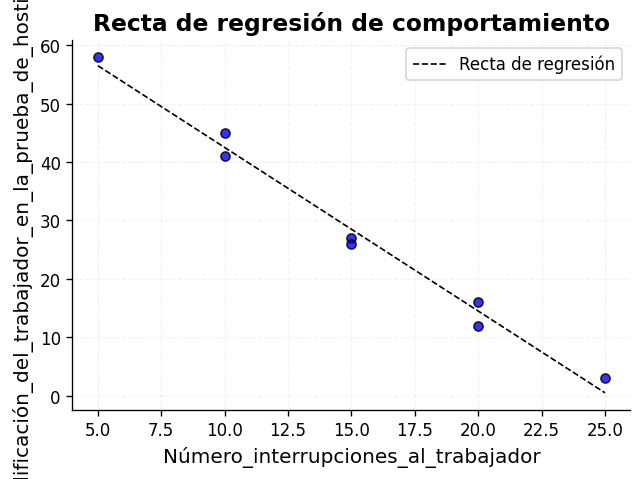

In [702]:
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    x, y,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia
    s=30,                 # tamaño de los puntos
    label='' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    x, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    'Recta de regresión de comportamiento',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'Número_interrupciones_al_trabajador',
    fontsize=12
)

plt.ylabel(
    'Calificación_del_trabajador_en_la_prueba_de_hostilidad',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    '',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico_dispersion_linea.png",
    bbox_inches='tight'
    )

plt.show()

In [703]:
# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,65.051384,75.948616
Número_interrupciones_al_trabajador,-3.136296,-2.463704


7. El intervalo de confianza del 95% para la pendiente es (-3.136, -2.464). Como no contiene el cero, existe evidencia de una relación negativa entre las variables.

valor-p (Shapiro) = 0.054816491127669634


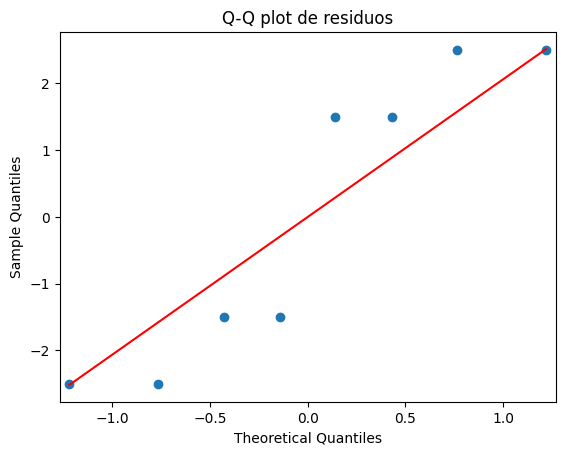

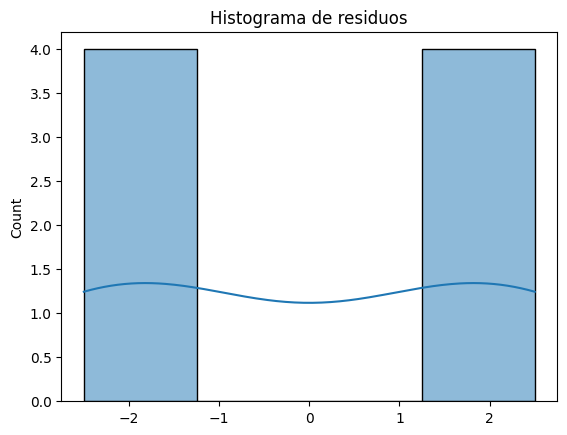

In [704]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

residuos = modelo.resid

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuos)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuos, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuos, kde=True)
plt.title("Histograma de residuos")
plt.show()

8. Los residuales se encuentran cerca de cero y no muestran un patrón evidente, por lo que los supuestos del modelo parecen cumplirse de manera razonable.

9. La prueba de Shapiro dio p = 0.055. Como es ligeramente mayor que 0.05, no se rechaza la normalidad de los residuales.

In [705]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuos, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor_p de Breusch-Pagan:  0.2482



10. La prueba de Breusch-Pagan dio p = 0.248. Como es mayor que 0.05, no existe evidencia suficiente de heterocedasticidad.

11. La recta de regresión es:

Y = 70.5 - 2.8X

Para 10 interrupciones, se obtiene una calificación estimada de 42.5.

Para 20 interrupciones, se obtiene una calificación estimada de 14.5.

Para 27 interrupciones, que está fuera del rango observado, se obtiene una estimación de -5.1. Esta extrapolación debe tomarse con precaución porque se encuentra fuera de los datos disponibles.

In [706]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols("Calificación_del_trabajador_en_la_prueba_de_hostilidad ~ Número_interrupciones_al_trabajador", data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Número_interrupciones_al_trabajador,1.0,2352.0,2352.000000,415.058824,9.090964e-07
Residual,6.0,34.0,5.666667,NaN,NaN


12. La prueba ANOVA dio F = 415.06 y p < 0.001. Por lo tanto, existe una relación lineal estadísticamente significativa entre el número de interrupciones y la calificación de la prueba.